In [1]:
# Cell 1 - Setup

import gc
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
RUN_MODE = "final"      # pilot or final
PROJECT_NAME = "UVIF-IoT-WiMob2026"

random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

except Exception as exc:
    raise RuntimeError(f"PyTorch is required but could not be imported: {exc}")


try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False


if IN_COLAB:
    try:
        drive.mount("/content/drive", force_remount=False)
        PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_NAME
    except Exception:
        PROJECT_ROOT = Path("/content") / PROJECT_NAME
else:
    PROJECT_ROOT = Path.cwd().resolve()


OUT_DIR = PROJECT_ROOT / "outputs"

AUDIT_DIR = OUT_DIR / "audit"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"
CKPT_DIR = OUT_DIR / "checkpoints"
FORENSIC_DIR = OUT_DIR / "forensics"
LOG_DIR = OUT_DIR / "logs"

for folder in [
    AUDIT_DIR,
    TABLE_DIR,
    FIG_DIR,
    MODEL_DIR,
    CKPT_DIR,
    FORENSIC_DIR,
    LOG_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


RUN_LOG_PATH = LOG_DIR / "run_log.txt"
SUMMARY_PATH = LOG_DIR / "run_summary.txt"

RUN_LOG_PATH.write_text("", encoding="utf-8")


def timestamp():
    return time.strftime("%H:%M:%S")


def log(message):
    line = f"[{timestamp()}] {message}"
    print(line)

    with open(RUN_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(line + "\n")


def write_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


if RUN_MODE == "pilot":
    MAX_TOTAL_ROWS = 300_000
    MAX_ROWS_PER_FILE = 25_000
    EPOCHS = 30
    RF_TREES = 100
    ADV_BATCH_CAP = 50
else:
    MAX_TOTAL_ROWS = 1_500_000
    MAX_ROWS_PER_FILE = 150_000
    EPOCHS = 50
    RF_TREES = 300
    ADV_BATCH_CAP = 200


CFG = {
    "max_total_rows": MAX_TOTAL_ROWS,
    "max_rows_per_file": MAX_ROWS_PER_FILE,
    "batch_size": 512,
    "epochs": EPOCHS,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "dropout": 0.30,
    "early_stop": 8,
    "ece_bins": 15,
    "pgd_steps": 10,
    "pgd_alpha": 0.004,
    "adv_batch_cap": ADV_BATCH_CAP,
    "rf_trees": RF_TREES,
    "feature_budgets": [5, 10, 15, 20, 30, 50, 115],
}


DATA_ROOTS = [
    PROJECT_ROOT / "data" / "nbaiot",
    PROJECT_ROOT / "data",
    PROJECT_ROOT.parent / "data" / "nbaiot",
    PROJECT_ROOT.parent / "data",
    PROJECT_ROOT,
]

if IN_COLAB:
    DATA_ROOTS.extend([
        Path("/content/drive/MyDrive/Datasets/nbaiot"),
        Path("/content/drive/MyDrive/Datasets/N_BaIoT"),
        Path("/content/drive/MyDrive/Datasets"),
        Path("/content"),
    ])


run_info = {
    "project": PROJECT_NAME,
    "run_mode": RUN_MODE,
    "seed": SEED,
    "colab": IN_COLAB,
    "project_root": str(PROJECT_ROOT),
    "device": str(DEVICE),
    "data_roots": [str(path) for path in DATA_ROOTS],
    "config": CFG,
}

write_json(run_info, AUDIT_DIR / "setup.json")

log(f"Project root: {PROJECT_ROOT}")
log(f"Output directory: {OUT_DIR}")
log(f"Run mode: {RUN_MODE}")
log(f"Device: {DEVICE}")

if DEVICE.type == "cuda":
    log(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    log("Running on CPU")

log("Setup complete")

[20:02:04] Project root: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026
[20:02:04] Output directory: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs
[20:02:04] Run mode: final
[20:02:04] Device: cuda
[20:02:04] GPU: NVIDIA RTX A1000 Laptop GPU
[20:02:04] Setup complete


In [2]:
# Cell 2 - Dataset loading

ATTACK_TOKENS = [
    "gafgyt", "mirai", "bashlite",
    "ack", "scan", "syn",
    "udpplain", "udp", "tcp",
    "junk", "combo", "http",
]


def get_label(path):
    text = str(path).lower()

    if "benign" in text:
        return 0

    if any(token in text for token in ATTACK_TOKENS):
        return 1

    return None


def get_attack_type(path):
    text = str(path).lower()

    if "benign" in text:
        return "benign"

    found = [token for token in ATTACK_TOKENS if token in text]
    return "+".join(found) if found else "attack"


def get_device(path):
    first_token = Path(path).stem.split(".")[0]
    return f"device_{first_token}" if first_token.isdigit() else "unknown"


def find_csv_files(search_roots):
    skip_dirs = {"outputs", ".git", ".ipynb_checkpoints", "__pycache__"}
    files = []

    for root in search_roots:
        root = Path(root)

        if not root.exists():
            continue

        for path in root.rglob("*.csv"):
            if any(part.lower() in skip_dirs for part in path.parts):
                continue

            label = get_label(path)
            if label is not None:
                files.append((path.resolve(), label))

    return sorted(set(files), key=lambda item: str(item[0]).lower())


def read_csv_sample(path, max_rows):
    data = pd.read_csv(path, low_memory=False)

    if len(data) > max_rows:
        data = data.sample(n=max_rows, random_state=SEED)

    return data.reset_index(drop=True)


nb_files = find_csv_files(DATA_ROOTS)
log(f"N-BaIoT files: {len(nb_files)}")

if not nb_files:
    raise FileNotFoundError("No N-BaIoT CSV files were found in the configured data roots.")


file_index = []

for path, label in nb_files:
    file_index.append({
        "source_file": str(path),
        "file_name": path.name,
        "device": get_device(path),
        "label": label,
        "label_name": "benign" if label == 0 else "attack",
        "attack_type": get_attack_type(path),
        "size_mb": round(path.stat().st_size / 1024**2, 4),
    })

file_index = pd.DataFrame(file_index)
file_index.to_csv(AUDIT_DIR / "nbaiot_file_index.csv", index=False)


frames = []
counts = {0: 0, 1: 0}
target_per_class = CFG["max_total_rows"] // 2

for path, label in nb_files:
    if counts[label] >= target_per_class:
        continue

    rows_needed = target_per_class - counts[label]
    rows_to_read = min(CFG["max_rows_per_file"], rows_needed)

    if rows_to_read <= 0:
        continue

    try:
        data = read_csv_sample(path, rows_to_read)

        data["label"] = label
        data["label_name"] = "benign" if label == 0 else "attack"
        data["source_file"] = str(path)
        data["source_file_name"] = path.name
        data["device"] = get_device(path)
        data["attack_type"] = get_attack_type(path)

        frames.append(data)
        counts[label] += len(data)

        log(f"{path.name:24s} {data['label_name'].iloc[0]:7s} {len(data):>8,} rows")

    except Exception as exc:
        log(f"Skipped {path}: {exc}")

    if min(counts.values()) >= target_per_class:
        break

    gc.collect()


if not frames:
    raise RuntimeError("CSV files were found, but none could be read.")


nbaiot_raw = pd.concat(frames, ignore_index=True)

class_size = nbaiot_raw["label"].value_counts().min()

nbaiot_raw = (
    nbaiot_raw
    .groupby("label", group_keys=False)
    .apply(lambda part: part.sample(n=class_size, random_state=SEED))
    .reset_index(drop=True)
)

meta_cols = [
    "label",
    "label_name",
    "source_file",
    "source_file_name",
    "device",
    "attack_type",
]

feature_cols = [
    col for col in nbaiot_raw.columns
    if col not in meta_cols and pd.api.types.is_numeric_dtype(nbaiot_raw[col])
]

dataset_audit = {
    "rows": int(nbaiot_raw.shape[0]),
    "columns": int(nbaiot_raw.shape[1]),
    "features": int(len(feature_cols)),
    "label_counts": nbaiot_raw["label_name"].value_counts().to_dict(),
    "device_counts": nbaiot_raw["device"].value_counts().to_dict(),
    "attack_type_counts": nbaiot_raw["attack_type"].value_counts().to_dict(),
    "missing_feature_values": int(nbaiot_raw[feature_cols].isna().sum().sum()),
    "duplicate_rows": int(nbaiot_raw.duplicated().sum()),
}

write_json(dataset_audit, AUDIT_DIR / "nbaiot_dataset_audit.json")
pd.DataFrame([dataset_audit]).to_csv(AUDIT_DIR / "nbaiot_dataset_audit.csv", index=False)

log(f"Loaded shape: {nbaiot_raw.shape}")
log(f"Features: {len(feature_cols)}")
log(f"Labels: {dataset_audit['label_counts']}")
log(f"Missing feature values: {dataset_audit['missing_feature_values']}")
log(f"Duplicate rows: {dataset_audit['duplicate_rows']}")
log("Dataset loading complete")

nbaiot_raw.head()

[20:10:16] N-BaIoT files: 89
[20:10:17] 1.benign.csv             benign    49,548 rows
[20:10:19] 1.gafgyt.combo.csv       attack    59,718 rows
[20:10:19] 1.gafgyt.junk.csv        attack    29,068 rows
[20:10:20] 1.gafgyt.scan.csv        attack    29,849 rows
[20:10:21] 1.gafgyt.tcp.csv         attack    92,141 rows
[20:10:22] 1.gafgyt.udp.csv         attack   105,874 rows
[20:10:24] 1.mirai.ack.csv          attack   102,195 rows
[20:10:25] 1.mirai.scan.csv         attack   107,685 rows
[20:10:28] 1.mirai.syn.csv          attack   122,573 rows
[20:10:32] 1.mirai.udp.csv          attack   100,897 rows
[20:10:32] 2.benign.csv             benign    13,113 rows
[20:10:33] 3.benign.csv             benign    39,100 rows
[20:10:37] 4.benign.csv             benign   150,000 rows
[20:10:38] 5.benign.csv             benign    62,154 rows
[20:10:40] 6.benign.csv             benign    98,514 rows
[20:10:41] 7.benign.csv             benign    52,150 rows
[20:10:42] 8.benign.csv             benign 

,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,label,label_name,source_file,source_file_name,device,attack_type
0,1.000000,60.000003,8.310310e-04,1.000023,60.006108,1.649012e+00,1.044894,71.600424,2997.544696,3.250071,...,84.852814,9.090000e-13,-9.330000e-29,0.000000e+00,0,benign,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,8.benign.csv,device_8,benign
1,5.554223,66.000000,9.090000e-13,5.724630,66.000000,0.000000e+00,5.951293,66.000110,0.002142,12.351191,...,116.392705,2.167145e+02,4.534572e-01,1.831883e-02,0,benign,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,4.benign.csv,device_4,benign
2,2.999923,89.999980,5.947660e-04,3.000331,89.996213,1.135928e-01,3.074760,89.280674,20.898323,6.614990,...,107.451157,2.664727e+01,-8.207032e-02,-4.012385e-02,0,benign,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,6.benign.csv,device_6,benign
3,2.989361,102.000000,0.000000e+00,2.993609,102.000000,3.640000e-12,2.997867,102.000000,0.000002,3.756109,...,144.249783,4.070000e-12,3.270000e-28,1.270000e-16,0,benign,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,1.benign.csv,device_1,benign
4,1.000164,89.997555,7.333162e-02,1.010950,89.837844,4.838387e+00,1.733218,83.658437,150.031475,6.616704,...,100.659179,1.992935e+02,9.820886e+00,6.956758e-01,0,benign,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,3.benign.csv,device_3,benign


In [3]:
# Cell 3 - Split and scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

meta_cols = [
    "label",
    "label_name",
    "source_file",
    "source_file_name",
    "device",
    "attack_type",
]

data = nbaiot_raw.replace([np.inf, -np.inf], np.nan).copy()

y = data["label"].astype(int).to_numpy()
row_id = np.arange(len(data))
X_raw = data[feature_cols].copy()

train_id, temp_id, y_train, y_temp = train_test_split(
    row_id,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

val_id, test_id, y_val, y_test = train_test_split(
    temp_id,
    y_temp,
    test_size=2 / 3,
    stratify=y_temp,
    random_state=SEED,
)

X_train_df = X_raw.iloc[train_id].copy()
X_val_df = X_raw.iloc[val_id].copy()
X_test_df = X_raw.iloc[test_id].copy()

feature_cols = X_train_df.columns[X_train_df.notna().any(axis=0)].tolist()
train_median = X_train_df[feature_cols].median(numeric_only=True).fillna(0)

X_train_df = X_train_df[feature_cols].fillna(train_median)
X_val_df = X_val_df[feature_cols].fillna(train_median)
X_test_df = X_test_df[feature_cols].fillna(train_median)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

meta_train = (
    data.iloc[train_id][meta_cols]
    .reset_index(drop=False)
    .rename(columns={"index": "original_index"})
)

meta_val = (
    data.iloc[val_id][meta_cols]
    .reset_index(drop=False)
    .rename(columns={"index": "original_index"})
)

meta_test = (
    data.iloc[test_id][meta_cols]
    .reset_index(drop=False)
    .rename(columns={"index": "original_index"})
)

meta_test.to_csv(AUDIT_DIR / "test_provenance.csv", index=False)
pd.DataFrame({"feature": feature_cols}).to_csv(AUDIT_DIR / "feature_columns.csv", index=False)


def make_loader(X, y, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        dataset,
        batch_size=CFG["batch_size"],
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )


train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

split_info = {
    "features": len(feature_cols),
    "train_shape": list(X_train.shape),
    "val_shape": list(X_val.shape),
    "test_shape": list(X_test.shape),
    "train_labels": {str(k): int(v) for k, v in zip(*np.unique(y_train, return_counts=True))},
    "val_labels": {str(k): int(v) for k, v in zip(*np.unique(y_val, return_counts=True))},
    "test_labels": {str(k): int(v) for k, v in zip(*np.unique(y_test, return_counts=True))},
}

write_json(split_info, AUDIT_DIR / "split_info.json")

log(f"Train: {X_train.shape}")
log(f"Validation: {X_val.shape}")
log(f"Test: {X_test.shape}")
log(f"Train labels: {split_info['train_labels']}")
log(f"Validation labels: {split_info['val_labels']}")
log(f"Test labels: {split_info['test_labels']}")
log("Split and scaling complete")

[20:13:01] Train: (742968, 115)
[20:13:01] Validation: (106138, 115)
[20:13:01] Test: (212278, 115)
[20:13:01] Train labels: {'0': 371484, '1': 371484}
[20:13:01] Validation labels: {'0': 53069, '1': 53069}
[20:13:01] Test labels: {'0': 106139, '1': 106139}
[20:13:01] Split and scaling complete


In [4]:
# Cell 4 - Models and metrics

import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)


class MLP(nn.Module):
    def __init__(self, in_dim, out_dim=2, hidden=(128, 64), dropout=0.2):
        super().__init__()

        blocks = []
        last_dim = in_dim

        for width in hidden:
            blocks.append(nn.Linear(last_dim, width))
            blocks.append(nn.ReLU())
            blocks.append(nn.Dropout(dropout))
            last_dim = width

        blocks.append(nn.Linear(last_dim, out_dim))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        temperature = torch.exp(self.log_temperature).clamp(0.05, 20.0)
        return logits / temperature

    @property
    def value(self):
        return float(torch.exp(self.log_temperature).detach().cpu().item())


def n_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def expected_calibration_error(y_true, probs, n_bins=15):
    confidence = probs.max(axis=1)
    prediction = probs.argmax(axis=1)
    correct = (prediction == y_true).astype(float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (confidence > lo) & (confidence <= hi)

        if not np.any(in_bin):
            continue

        acc_bin = correct[in_bin].mean()
        conf_bin = confidence[in_bin].mean()
        ece += in_bin.mean() * abs(acc_bin - conf_bin)

    return float(ece)


def predict_nn(model, loader, temperature=None):
    model.eval()

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)

            if temperature is not None:
                logits = temperature(logits)

            probs = F.softmax(logits, dim=1)

            probs_list.append(probs.cpu().numpy())
            labels_list.append(y.numpy())

    probs = np.vstack(probs_list)
    labels = np.concatenate(labels_list)
    preds = probs.argmax(axis=1)

    return probs, preds, labels


def classification_metrics(y_true, y_pred, probs):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "ece": expected_calibration_error(y_true, probs, CFG["ece_bins"]),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, probs[:, 1])
    except Exception:
        metrics["roc_auc"] = np.nan

    try:
        metrics["pr_auc"] = average_precision_score(y_true, probs[:, 1])
    except Exception:
        metrics["pr_auc"] = np.nan

    try:
        metrics["nll"] = log_loss(y_true, probs, labels=[0, 1])
    except Exception:
        metrics["nll"] = np.nan

    try:
        metrics["brier"] = brier_score_loss(y_true, probs[:, 1])
    except Exception:
        metrics["brier"] = np.nan

    return metrics


def save_latex_table(df, path, index=True):
    try:
        df.to_latex(path, index=index, float_format="%.4f")
    except Exception as exc:
        log(f"Could not write {path.name}: {exc}")


log("Models and metric functions loaded")

[20:14:08] Models and metric functions loaded


In [5]:
# Cell 5 - Training

if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()


def train_network(model, loader_train, loader_val, name, epochs=None):
    epochs = epochs or CFG["epochs"]

    model.to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CFG["learning_rate"],
        weight_decay=CFG["weight_decay"],
    )

    best_f1 = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(epochs):
        model.train()

        for x, y in loader_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            loss = F.cross_entropy(model(x), y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        probs, preds, labels = predict_nn(model, loader_val)
        val_f1 = f1_score(labels, preds, zero_division=0)
        history.append(val_f1)

        improved = val_f1 > best_f1 + 1e-4

        if improved:
            best_f1 = val_f1
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            patience = 0
        else:
            patience += 1

        if epoch == 0 or (epoch + 1) % 5 == 0:
            log(f"{name}: epoch {epoch + 1:02d}/{epochs}, val_f1={val_f1:.4f}")

        if patience >= CFG["early_stop"]:
            log(f"{name}: stopped at epoch {epoch + 1}, best_val_f1={best_f1:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def make_subset_loader(X, y, columns, shuffle=False):
    return make_loader(X[:, columns], y, shuffle=shuffle)


models = {}
history = {}

log("Training logistic regression")
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)
log_reg.fit(X_train, y_train)

models["Logistic Regression"] = log_reg
joblib.dump(log_reg, MODEL_DIR / "logistic_regression.joblib")


log("Training random forest")
forest = RandomForestClassifier(
    n_estimators=CFG["rf_trees"],
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    max_samples=0.7,
    bootstrap=True,
)
forest.fit(X_train, y_train)

models["Random Forest"] = forest
joblib.dump(forest, MODEL_DIR / "random_forest.joblib")


feature_rank = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": forest.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_rank["rank"] = np.arange(1, len(feature_rank) + 1)
feature_rank.to_csv(TABLE_DIR / "rf_feature_importance.csv", index=False)


uvif_k = 30
uvif_features = feature_rank.head(uvif_k)["feature"].tolist()
uvif_cols = [feature_cols.index(name) for name in uvif_features]

pd.DataFrame({"feature": uvif_features}).to_csv(
    TABLE_DIR / f"uvif_top_{uvif_k}_features.csv",
    index=False,
)


log("Training standard MLP")
mlp = MLP(
    in_dim=X_train.shape[1],
    out_dim=2,
    hidden=(128, 64),
    dropout=CFG["dropout"],
)

history["Standard MLP"] = train_network(
    mlp,
    train_loader,
    val_loader,
    name="Standard MLP",
)

models["Standard MLP"] = mlp

torch.save(
    {
        "state_dict": mlp.state_dict(),
        "features": feature_cols,
        "input_dim": X_train.shape[1],
    },
    CKPT_DIR / "standard_mlp.pt",
)


log(f"Training UVIF-IoT on {uvif_k} selected features")
uvif_train_loader = make_subset_loader(X_train, y_train, uvif_cols, shuffle=True)
uvif_val_loader = make_subset_loader(X_val, y_val, uvif_cols)
uvif_test_loader = make_subset_loader(X_test, y_test, uvif_cols)

uvif_model = MLP(
    in_dim=uvif_k,
    out_dim=2,
    hidden=(64, 32),
    dropout=CFG["dropout"],
)

history["UVIF-IoT"] = train_network(
    uvif_model,
    uvif_train_loader,
    uvif_val_loader,
    name="UVIF-IoT",
)

models["UVIF-IoT"] = uvif_model

torch.save(
    {
        "state_dict": uvif_model.state_dict(),
        "features": uvif_features,
        "feature_indices": uvif_cols,
        "input_dim": uvif_k,
    },
    CKPT_DIR / "uvif_iot_top30.pt",
)


max_epochs = max(len(values) for values in history.values())
history_df = pd.DataFrame({
    name: values + [np.nan] * (max_epochs - len(values))
    for name, values in history.items()
})

history_df.index = np.arange(1, max_epochs + 1)
history_df.index.name = "epoch"
history_df.to_csv(TABLE_DIR / "validation_f1_history.csv")

joblib.dump(scaler, MODEL_DIR / "standard_scaler.joblib")
write_json(feature_cols, MODEL_DIR / "feature_columns.json")
write_json(uvif_features, MODEL_DIR / "uvif_top30_features.json")

training_info = {
    "models": list(models.keys()),
    "full_features": len(feature_cols),
    "uvif_features": len(uvif_features),
    "feature_reduction_pct": 100 * (1 - len(uvif_features) / len(feature_cols)),
    "mlp_parameters": n_parameters(mlp),
    "uvif_parameters": n_parameters(uvif_model),
}

write_json(training_info, AUDIT_DIR / "training_summary.json")

MODELS = models
HIST = history
rf_rank = feature_rank
top_k_uvif = uvif_k
uvif = uvif_model

log(f"Models trained: {list(MODELS.keys())}")
log(f"UVIF-IoT feature reduction: {training_info['feature_reduction_pct']:.1f}%")
log("Training complete")

[20:15:07] Training logistic regression
[20:15:18] Training random forest
[20:16:05] Training standard MLP
[20:16:26] Standard MLP: epoch 01/50, val_f1=0.9995
[20:17:41] Standard MLP: epoch 05/50, val_f1=0.9996
[20:19:17] Standard MLP: epoch 10/50, val_f1=0.9996
[20:20:51] Standard MLP: epoch 15/50, val_f1=0.9997
[20:21:10] Standard MLP: stopped at epoch 16, best_val_f1=0.9997
[20:21:10] Training UVIF-IoT on 30 selected features
[20:21:20] UVIF-IoT: epoch 01/50, val_f1=0.9991
[20:22:01] UVIF-IoT: epoch 05/50, val_f1=0.9996
[20:22:51] UVIF-IoT: epoch 10/50, val_f1=0.9997
[20:23:12] UVIF-IoT: stopped at epoch 12, best_val_f1=0.9996
[20:23:12] Models trained: ['Logistic Regression', 'Random Forest', 'Standard MLP', 'UVIF-IoT']
[20:23:12] UVIF-IoT feature reduction: 73.9%
[20:23:12] Training complete


In [6]:
# Cell 6 - Test evaluation and calibration

def predict_classical(model, X, y):
    probs = model.predict_proba(X)
    preds = probs.argmax(axis=1)
    return probs, preds, y


def fit_temperature(model, loader):
    model.eval()

    logits = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)

            logits.append(model(x).detach())
            labels.append(y.to(DEVICE))

    logits = torch.cat(logits)
    labels = torch.cat(labels)

    temperature = TemperatureScaler().to(DEVICE)
    optimizer = torch.optim.LBFGS(
        [temperature.log_temperature],
        lr=0.1,
        max_iter=50,
    )

    def closure():
        optimizer.zero_grad()
        loss = F.cross_entropy(temperature(logits), labels)
        loss.backward()
        return loss

    optimizer.step(closure)

    return temperature


results = {}
probs_store = {}
pred_store = {}
target_store = {}

probs, preds, labels = predict_classical(MODELS["Logistic Regression"], X_test, y_test)
results["Logistic Regression"] = classification_metrics(labels, preds, probs)
probs_store["Logistic Regression"] = probs
pred_store["Logistic Regression"] = preds
target_store["Logistic Regression"] = labels

probs, preds, labels = predict_classical(MODELS["Random Forest"], X_test, y_test)
results["Random Forest"] = classification_metrics(labels, preds, probs)
probs_store["Random Forest"] = probs
pred_store["Random Forest"] = preds
target_store["Random Forest"] = labels

probs, preds, labels = predict_nn(MODELS["Standard MLP"], test_loader)
results["Standard MLP"] = classification_metrics(labels, preds, probs)
probs_store["Standard MLP"] = probs
pred_store["Standard MLP"] = preds
target_store["Standard MLP"] = labels

mlp_temperature = fit_temperature(MODELS["Standard MLP"], val_loader)

probs, preds, labels = predict_nn(
    MODELS["Standard MLP"],
    test_loader,
    temperature=mlp_temperature,
)
results["Standard MLP + T"] = classification_metrics(labels, preds, probs)
probs_store["Standard MLP + T"] = probs
pred_store["Standard MLP + T"] = preds
target_store["Standard MLP + T"] = labels

probs, preds, labels = predict_nn(MODELS["UVIF-IoT"], uvif_test_loader)
results["UVIF-IoT"] = classification_metrics(labels, preds, probs)
probs_store["UVIF-IoT"] = probs
pred_store["UVIF-IoT"] = preds
target_store["UVIF-IoT"] = labels

uvif_temperature = fit_temperature(MODELS["UVIF-IoT"], uvif_val_loader)

probs, preds, labels = predict_nn(
    MODELS["UVIF-IoT"],
    uvif_test_loader,
    temperature=uvif_temperature,
)
results["UVIF-IoT + T"] = classification_metrics(labels, preds, probs)
probs_store["UVIF-IoT + T"] = probs
pred_store["UVIF-IoT + T"] = preds
target_store["UVIF-IoT + T"] = labels


clean_df = pd.DataFrame(results).T
clean_df.to_csv(TABLE_DIR / "clean_calibrated_metrics.csv")
save_latex_table(clean_df, TABLE_DIR / "table_clean_calibrated_metrics.tex")

for name in results:
    cm = confusion_matrix(target_store[name], pred_store[name], labels=[0, 1])

    cm_df = pd.DataFrame(
        cm,
        index=["true_benign", "true_attack"],
        columns=["pred_benign", "pred_attack"],
    )

    file_name = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
    )

    cm_df.to_csv(TABLE_DIR / f"confusion_matrix_{file_name}.csv")


temperature_summary = {
    "standard_mlp": mlp_temperature.value,
    "uvif_iot": uvif_temperature.value,
}

write_json(temperature_summary, TABLE_DIR / "temperature_scaling.json")

PROBS = probs_store
PREDS = pred_store
TARGETS = target_store
RESULTS = results

mlp_temp = mlp_temperature
uvif_temp = uvif_temperature

for name, row in clean_df.iterrows():
    log(
        f"{name:20s} "
        f"acc={row['accuracy']:.4f} "
        f"f1={row['f1']:.4f} "
        f"auc={row['roc_auc']:.4f} "
        f"ece={row['ece']:.6f}"
    )

log(f"Standard MLP temperature: {mlp_temperature.value:.4f}")
log(f"UVIF-IoT temperature: {uvif_temperature.value:.4f}")
log("Evaluation complete")

clean_df

[20:34:09] Logistic Regression  acc=0.9991 f1=0.9991 auc=0.9999 ece=0.000298
[20:34:09] Random Forest        acc=1.0000 f1=1.0000 auc=1.0000 ece=0.000058
[20:34:09] Standard MLP         acc=0.9996 f1=0.9996 auc=1.0000 ece=0.000220
[20:34:09] Standard MLP + T     acc=0.9996 f1=0.9996 auc=1.0000 ece=0.000224
[20:34:09] UVIF-IoT             acc=0.9997 f1=0.9997 auc=1.0000 ece=0.000218
[20:34:09] UVIF-IoT + T         acc=0.9997 f1=0.9997 auc=1.0000 ece=0.000068
[20:34:09] Standard MLP temperature: 1.0039
[20:34:09] UVIF-IoT temperature: 1.2074
[20:34:09] Evaluation complete


,accuracy,balanced_accuracy,precision,recall,f1,ece,roc_auc,pr_auc,nll,brier
Logistic Regression,0.999143,0.999143,0.998579,0.999708,0.999143,0.000298,0.999897,0.999928,0.004597,0.000747
Random Forest,0.999958,0.999958,1.000000,0.999915,0.999958,0.000058,0.999995,0.999995,0.000306,0.000034
Standard MLP,0.999637,0.999637,0.999538,0.999736,0.999637,0.000220,0.999980,0.999966,0.002122,0.000336
Standard MLP + T,0.999637,0.999637,0.999538,0.999736,0.999637,0.000224,0.999981,0.999966,0.002116,0.000336
UVIF-IoT,0.999651,0.999651,0.999604,0.999699,0.999651,0.000218,0.999982,0.999983,0.002031,0.000325
UVIF-IoT + T,0.999651,0.999651,0.999604,0.999699,0.999651,0.000068,0.999982,0.999983,0.001934,0.000322


In [7]:
# Cell 7 - Triage outputs

def build_event_ledger(model_name):
    probs = PROBS[model_name]
    preds = PREDS[model_name]
    labels = TARGETS[model_name]

    confidence = probs.max(axis=1)
    attack_prob = probs[:, 1]

    entropy = -(probs * np.log(probs + 1e-12)).sum(axis=1)
    entropy_norm = entropy / np.log(probs.shape[1])

    ledger_out = meta_test.copy()

    ledger_out["true_label"] = labels
    ledger_out["pred_label"] = preds
    ledger_out["true_label_name"] = np.where(labels == 1, "attack", "benign")
    ledger_out["pred_label_name"] = np.where(preds == 1, "attack", "benign")

    ledger_out["attack_probability"] = attack_prob
    ledger_out["confidence"] = confidence
    ledger_out["confidence_uncertainty"] = 1.0 - confidence
    ledger_out["entropy"] = entropy
    ledger_out["entropy_norm"] = entropy_norm
    ledger_out["correct"] = (preds == labels).astype(int)

    ledger_out["priority_score"] = (
        0.50 * ledger_out["attack_probability"]
        + 0.30 * ledger_out["entropy_norm"]
        + 0.20 * ledger_out["confidence_uncertainty"]
    )

    ledger_out["model"] = model_name

    return ledger_out


ledger = build_event_ledger("UVIF-IoT + T")
ledger.to_csv(FORENSIC_DIR / "event_ledger.csv", index=False)

top_uncertain = (
    ledger
    .sort_values(["entropy_norm", "priority_score"], ascending=False)
    .head(100)
)

high_risk_uncertain = (
    ledger[
        (ledger["pred_label"] == 1)
        & (ledger["entropy_norm"] >= ledger["entropy_norm"].quantile(0.95))
    ]
    .sort_values("priority_score", ascending=False)
    .head(100)
)

false_negatives = (
    ledger[
        (ledger["true_label"] == 1)
        & (ledger["pred_label"] == 0)
    ]
    .sort_values("confidence", ascending=False)
    .head(100)
)

false_positives = (
    ledger[
        (ledger["true_label"] == 0)
        & (ledger["pred_label"] == 1)
    ]
    .sort_values("confidence", ascending=False)
    .head(100)
)

top_priority = (
    ledger
    .sort_values("priority_score", ascending=False)
    .head(100)
)

top_uncertain.to_csv(FORENSIC_DIR / "top_uncertain_events.csv", index=False)
high_risk_uncertain.to_csv(FORENSIC_DIR / "high_risk_uncertain_events.csv", index=False)
false_negatives.to_csv(FORENSIC_DIR / "false_negatives_for_review.csv", index=False)
false_positives.to_csv(FORENSIC_DIR / "false_positives_for_review.csv", index=False)
top_priority.to_csv(FORENSIC_DIR / "top_priority_events.csv", index=False)

triage_by_group = (
    ledger
    .groupby(["device", "attack_type", "true_label_name"])
    .agg(
        samples=("true_label", "size"),
        detection_rate=("correct", "mean"),
        mean_attack_probability=("attack_probability", "mean"),
        mean_confidence=("confidence", "mean"),
        mean_entropy=("entropy_norm", "mean"),
        mean_priority=("priority_score", "mean"),
    )
    .reset_index()
)

triage_by_group.to_csv(FORENSIC_DIR / "device_attack_summary.csv", index=False)
save_latex_table(
    triage_by_group.head(20),
    FORENSIC_DIR / "table_device_attack_summary.tex",
    index=False,
)

triage_summary = {
    "events": int(len(ledger)),
    "false_negatives": int(((ledger["true_label"] == 1) & (ledger["pred_label"] == 0)).sum()),
    "false_positives": int(((ledger["true_label"] == 0) & (ledger["pred_label"] == 1)).sum()),
    "mean_confidence": float(ledger["confidence"].mean()),
    "mean_entropy_norm": float(ledger["entropy_norm"].mean()),
    "mean_priority_score": float(ledger["priority_score"].mean()),
    "priority_score": "0.50*attack_probability + 0.30*entropy_norm + 0.20*confidence_uncertainty",
}

write_json(triage_summary, FORENSIC_DIR / "triage_summary.json")

log(f"Ledger rows: {triage_summary['events']:,}")
log(f"False negatives: {triage_summary['false_negatives']}")
log(f"False positives: {triage_summary['false_positives']}")
log(f"Mean entropy: {triage_summary['mean_entropy_norm']:.6f}")
log("Triage outputs saved")

triage_by_group.head(20)

[20:37:06] Ledger rows: 212,278
[20:37:06] False negatives: 32
[20:37:06] False positives: 42
[20:37:06] Mean entropy: 0.003352
[20:37:06] Triage outputs saved


,device,attack_type,true_label_name,samples,detection_rate,mean_attack_probability,mean_confidence,mean_entropy,mean_priority
0,device_1,benign,benign,9965,0.999900,0.000280,0.999820,1.522235e-03,0.000633
1,device_1,gafgyt+combo,attack,8474,1.000000,1.000000,1.000000,1.027066e-10,0.500000
2,device_1,gafgyt+junk,attack,4054,0.999507,0.999524,0.999983,9.047211e-05,0.499792
3,device_1,gafgyt+scan,attack,4247,0.999058,0.998740,0.999178,3.275620e-03,0.500517
4,device_1,gafgyt+tcp,attack,13139,0.999163,0.998088,0.998723,1.349283e-02,0.503347
5,device_1,gafgyt+udp,attack,15116,0.999206,0.998044,0.998810,1.320691e-02,0.503222
6,device_1,mirai+ack,attack,14364,0.999930,0.999930,1.000000,1.146734e-06,0.499966
7,device_1,mirai+scan,attack,15057,0.999934,0.999952,0.999981,5.843566e-05,0.499997
8,device_1,mirai+syn,attack,17437,0.999943,0.999943,1.000000,7.580077e-07,0.499972
9,device_1,mirai+udp,attack,14251,1.000000,1.000000,1.000000,9.589375e-07,0.500000


In [8]:
# Cell 8 - Robustness check

def fgsm(model, x, y, epsilon):
    x_adv = x.detach().clone()
    x_adv.requires_grad_(True)

    loss = F.cross_entropy(model(x_adv), y)
    grad = torch.autograd.grad(loss, x_adv)[0]

    return (x_adv + epsilon * grad.sign()).detach()


def pgd(model, x, y, epsilon, step_size, steps):
    x0 = x.detach()
    x_adv = x0.clone()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv.detach() + step_size * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x0 + epsilon), x0 - epsilon)

    return x_adv.detach()


def f1_on_batches(model, loader, batch_limit=None):
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(loader):
            if batch_limit is not None and batch_idx >= batch_limit:
                break

            x = x.to(DEVICE)
            pred = model(x).argmax(dim=1)

            preds.extend(pred.cpu().numpy())
            labels.extend(y.numpy())

    return f1_score(labels, preds, zero_division=0)


def f1_under_perturbation(model, loader, method, epsilon, batch_limit=None):
    model.eval()

    preds = []
    labels = []

    for batch_idx, (x, y) in enumerate(loader):
        if batch_limit is not None and batch_idx >= batch_limit:
            break

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if method == "fgsm":
            x_eval = fgsm(model, x, y, epsilon)
        elif method == "pgd":
            x_eval = pgd(
                model,
                x,
                y,
                epsilon=epsilon,
                step_size=CFG["pgd_alpha"],
                steps=CFG["pgd_steps"],
            )
        else:
            raise ValueError("method must be 'fgsm' or 'pgd'")

        with torch.no_grad():
            pred = model(x_eval).argmax(dim=1)

        preds.extend(pred.cpu().numpy())
        labels.extend(y.cpu().numpy())

    return f1_score(labels, preds, zero_division=0)


eps_values = [0.005, 0.01, 0.02]
batch_limit = CFG["adv_batch_cap"]

robustness_models = {
    "Standard MLP": (MODELS["Standard MLP"], test_loader),
    "UVIF-IoT": (MODELS["UVIF-IoT"], uvif_test_loader),
}

rows = []

for name, (model, loader) in robustness_models.items():
    model.to(DEVICE)

    row = {
        "model": name,
        "clean_subset_f1": f1_on_batches(model, loader, batch_limit),
    }

    for eps in eps_values:
        row[f"fgsm_{eps}"] = f1_under_perturbation(
            model,
            loader,
            method="fgsm",
            epsilon=eps,
            batch_limit=batch_limit,
        )

        row[f"pgd_{eps}"] = f1_under_perturbation(
            model,
            loader,
            method="pgd",
            epsilon=eps,
            batch_limit=batch_limit,
        )

    rows.append(row)

    log(
        f"{name:12s} "
        f"clean={row['clean_subset_f1']:.4f}, "
        f"FGSM(0.01)={row['fgsm_0.01']:.4f}, "
        f"PGD(0.02)={row['pgd_0.02']:.4f}"
    )


adv_df = pd.DataFrame(rows).set_index("model")
adv_df.to_csv(TABLE_DIR / "adversarial_robustness.csv")
save_latex_table(adv_df, TABLE_DIR / "table_adversarial_robustness.tex")

log("Robustness check complete")

adv_df

[20:40:28] Standard MLP clean=0.9996, FGSM(0.01)=0.9996, PGD(0.02)=0.9993
[20:40:41] UVIF-IoT     clean=0.9996, FGSM(0.01)=0.9995, PGD(0.02)=0.9995
[20:40:41] Robustness check complete


,clean_subset_f1,fgsm_0.005,pgd_0.005,fgsm_0.01,pgd_0.01,fgsm_0.02,pgd_0.02
model,,,,,,,
Standard MLP,0.999619,0.99957,0.99957,0.999551,0.999551,0.999306,0.999306
UVIF-IoT,0.999648,0.99959,0.99959,0.999541,0.999541,0.999453,0.999453


In [9]:
# Cell 9 - Inference cost

def size_kb(path):
    path = Path(path)
    return round(path.stat().st_size / 1024, 2) if path.exists() else np.nan


def time_network(model, X, repeats=5, batch_size=1024, device="cpu"):
    model = model.to(device)
    model.eval()

    X_tensor = torch.tensor(X, dtype=torch.float32)
    n_samples = len(X_tensor)

    with torch.no_grad():
        for start in range(0, min(n_samples, 2 * batch_size), batch_size):
            batch = X_tensor[start:start + batch_size].to(device)
            _ = model(batch)

    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = []

    with torch.no_grad():
        for _ in range(repeats):
            start_time = time.perf_counter()

            for start in range(0, n_samples, batch_size):
                batch = X_tensor[start:start + batch_size].to(device)
                _ = model(batch)

            if device == "cuda":
                torch.cuda.synchronize()

            elapsed.append(time.perf_counter() - start_time)

    mean_time = float(np.mean(elapsed))

    return {
        "ms_per_sample": 1000 * mean_time / n_samples,
        "samples_per_sec": n_samples / mean_time,
    }


def time_classical(model, X, repeats=5):
    _ = model.predict_proba(X[: min(len(X), 2048)])

    elapsed = []

    for _ in range(repeats):
        start_time = time.perf_counter()
        _ = model.predict_proba(X)
        elapsed.append(time.perf_counter() - start_time)

    mean_time = float(np.mean(elapsed))

    return {
        "ms_per_sample": 1000 * mean_time / len(X),
        "samples_per_sec": len(X) / mean_time,
    }


n_latency = min(20_000, len(X_test))

X_full_latency = X_test[:n_latency]
X_uvif_latency = X_test[:n_latency, uvif_cols]

rows = []

lr_time = time_classical(MODELS["Logistic Regression"], X_full_latency)
rows.append({
    "model": "Logistic Regression",
    "features": len(feature_cols),
    "feature_reduction_pct": 0.0,
    "parameters": np.nan,
    "size_kb": size_kb(MODEL_DIR / "logistic_regression.joblib"),
    "cpu_ms_per_sample": lr_time["ms_per_sample"],
    "cpu_samples_per_sec": lr_time["samples_per_sec"],
    "gpu_ms_per_sample": np.nan,
    "gpu_samples_per_sec": np.nan,
})

rf_time = time_classical(MODELS["Random Forest"], X_full_latency)
rows.append({
    "model": "Random Forest",
    "features": len(feature_cols),
    "feature_reduction_pct": 0.0,
    "parameters": np.nan,
    "size_kb": size_kb(MODEL_DIR / "random_forest.joblib"),
    "cpu_ms_per_sample": rf_time["ms_per_sample"],
    "cpu_samples_per_sec": rf_time["samples_per_sec"],
    "gpu_ms_per_sample": np.nan,
    "gpu_samples_per_sec": np.nan,
})

mlp_cpu = time_network(MODELS["Standard MLP"], X_full_latency, device="cpu")

if torch.cuda.is_available():
    mlp_gpu = time_network(MODELS["Standard MLP"], X_full_latency, device="cuda")
else:
    mlp_gpu = {"ms_per_sample": np.nan, "samples_per_sec": np.nan}

rows.append({
    "model": "Standard MLP",
    "features": len(feature_cols),
    "feature_reduction_pct": 0.0,
    "parameters": n_parameters(MODELS["Standard MLP"]),
    "size_kb": size_kb(CKPT_DIR / "standard_mlp.pt"),
    "cpu_ms_per_sample": mlp_cpu["ms_per_sample"],
    "cpu_samples_per_sec": mlp_cpu["samples_per_sec"],
    "gpu_ms_per_sample": mlp_gpu["ms_per_sample"],
    "gpu_samples_per_sec": mlp_gpu["samples_per_sec"],
})

uvif_cpu = time_network(MODELS["UVIF-IoT"], X_uvif_latency, device="cpu")

if torch.cuda.is_available():
    uvif_gpu = time_network(MODELS["UVIF-IoT"], X_uvif_latency, device="cuda")
else:
    uvif_gpu = {"ms_per_sample": np.nan, "samples_per_sec": np.nan}

rows.append({
    "model": "UVIF-IoT",
    "features": len(uvif_cols),
    "feature_reduction_pct": 100 * (1 - len(uvif_cols) / len(feature_cols)),
    "parameters": n_parameters(MODELS["UVIF-IoT"]),
    "size_kb": size_kb(CKPT_DIR / "uvif_iot_top30.pt"),
    "cpu_ms_per_sample": uvif_cpu["ms_per_sample"],
    "cpu_samples_per_sec": uvif_cpu["samples_per_sec"],
    "gpu_ms_per_sample": uvif_gpu["ms_per_sample"],
    "gpu_samples_per_sec": uvif_gpu["samples_per_sec"],
})

edge_df = pd.DataFrame(rows)

edge_df.to_csv(TABLE_DIR / "edge_efficiency_summary.csv", index=False)
save_latex_table(
    edge_df,
    TABLE_DIR / "table_edge_efficiency_summary.tex",
    index=False,
)

log(f"Latency samples: {n_latency:,}")
log("Inference-cost summary saved")

edge_df

[20:43:27] Latency samples: 20,000
[20:43:27] Inference-cost summary saved


,model,features,feature_reduction_pct,parameters,size_kb,cpu_ms_per_sample,cpu_samples_per_sec,gpu_ms_per_sample,gpu_samples_per_sec
0,Logistic Regression,115,0.000000,NaN,1.76,0.000457,2.187461e+06,NaN,NaN
1,Random Forest,115,0.000000,NaN,3437.35,0.005447,1.835713e+05,NaN,NaN
2,Standard MLP,115,0.000000,23234.0,96.39,0.000401,2.495178e+06,0.002530,3.952485e+05
3,UVIF-IoT,30,73.913043,4130.0,20.10,0.000220,4.546157e+06,0.000619,1.614974e+06


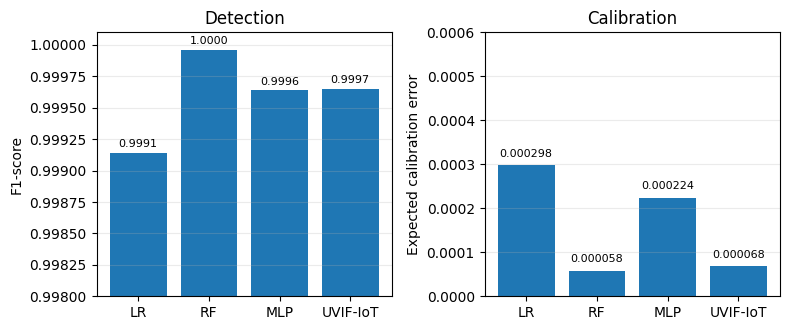

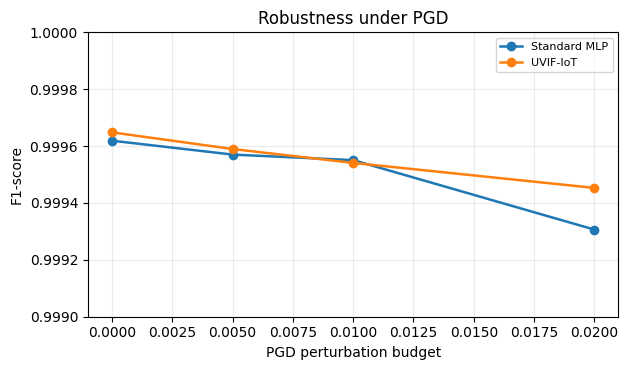

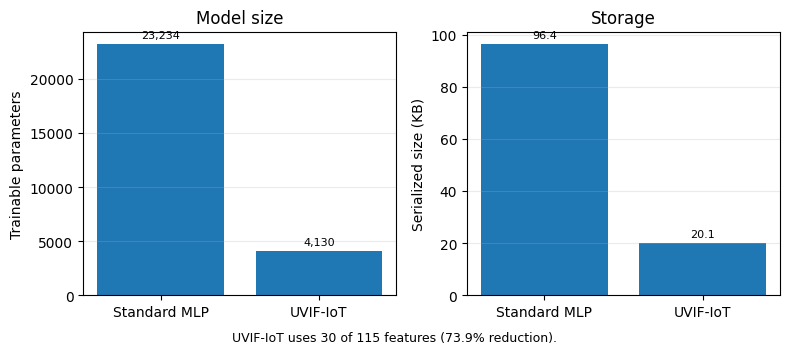

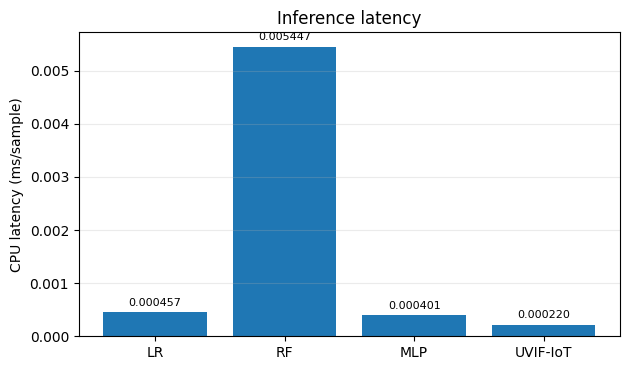

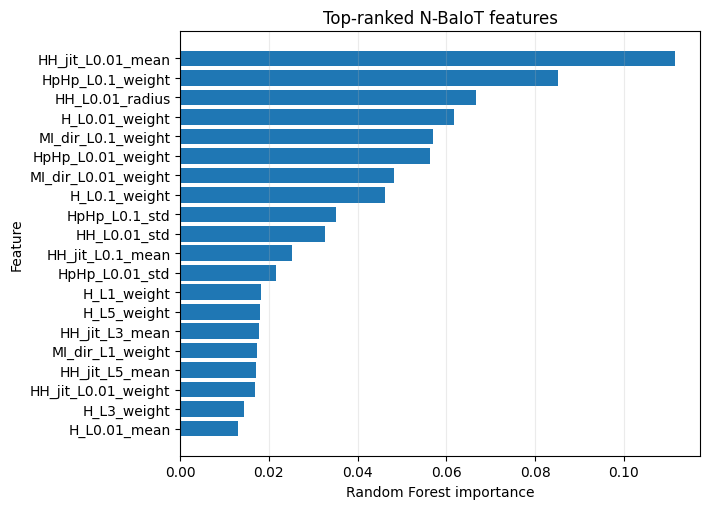

[20:44:56] Figures saved


,figure,description,pdf,png
0,fig_detection_calibration,Detection and calibration metrics,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
1,fig_pgd_robustness,PGD robustness comparison,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
2,fig_model_cost,Parameter count and serialized size,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
3,fig_cpu_latency,CPU inference latency,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
4,fig_rf_feature_importance,Top Random-Forest-ranked features,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...


In [10]:
# Cell 10 - Figures

import matplotlib.pyplot as plt

def save_figure(name):
    plt.savefig(FIG_DIR / f"{name}.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")


model_order = [
    "Logistic Regression",
    "Random Forest",
    "Standard MLP + T",
    "UVIF-IoT + T",
]

model_labels = ["LR", "RF", "MLP", "UVIF-IoT"]

metric_plot = clean_df.loc[model_order].copy()
metric_plot.index = model_labels


fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.4))

axes[0].bar(metric_plot.index, metric_plot["f1"])
axes[0].set_ylabel("F1-score")
axes[0].set_title("Detection")
axes[0].set_ylim(0.998, 1.0001)
axes[0].grid(axis="y", alpha=0.25)

for i, value in enumerate(metric_plot["f1"]):
    axes[0].text(
        i,
        value + 0.00003,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[1].bar(metric_plot.index, metric_plot["ece"])
axes[1].set_ylabel("Expected calibration error")
axes[1].set_title("Calibration")
axes[1].set_ylim(0, max(0.0006, metric_plot["ece"].max() * 1.35))
axes[1].grid(axis="y", alpha=0.25)

for i, value in enumerate(metric_plot["ece"]):
    axes[1].text(
        i,
        value + 0.000015,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
save_figure("fig_detection_calibration")
plt.show()


pgd_plot = adv_df.copy()
eps = np.array([0.0, 0.005, 0.01, 0.02])

plt.figure(figsize=(6.4, 3.8))

for model_name in ["Standard MLP", "UVIF-IoT"]:
    values = [
        pgd_plot.loc[model_name, "clean_subset_f1"],
        pgd_plot.loc[model_name, "pgd_0.005"],
        pgd_plot.loc[model_name, "pgd_0.01"],
        pgd_plot.loc[model_name, "pgd_0.02"],
    ]

    plt.plot(eps, values, marker="o", linewidth=1.8, label=model_name)

plt.xlabel("PGD perturbation budget")
plt.ylabel("F1-score")
plt.title("Robustness under PGD")
plt.ylim(0.9990, 1.0000)
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
save_figure("fig_pgd_robustness")
plt.show()


edge_plot = edge_df.set_index("model").loc[["Standard MLP", "UVIF-IoT"]]

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.4))

axes[0].bar(edge_plot.index, edge_plot["parameters"])
axes[0].set_ylabel("Trainable parameters")
axes[0].set_title("Model size")
axes[0].grid(axis="y", alpha=0.25)

for i, value in enumerate(edge_plot["parameters"]):
    axes[0].text(
        i,
        value + edge_plot["parameters"].max() * 0.015,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[1].bar(edge_plot.index, edge_plot["size_kb"])
axes[1].set_ylabel("Serialized size (KB)")
axes[1].set_title("Storage")
axes[1].grid(axis="y", alpha=0.25)

for i, value in enumerate(edge_plot["size_kb"]):
    axes[1].text(
        i,
        value + edge_plot["size_kb"].max() * 0.015,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.text(
    0.5,
    -0.02,
    f"UVIF-IoT uses {len(uvif_cols)} of {len(feature_cols)} features "
    f"({100 * (1 - len(uvif_cols) / len(feature_cols)):.1f}% reduction).",
    ha="center",
    fontsize=9,
)

plt.tight_layout()
save_figure("fig_model_cost")
plt.show()


latency_plot = (
    edge_df
    .set_index("model")
    .loc[["Logistic Regression", "Random Forest", "Standard MLP", "UVIF-IoT"]]
    .copy()
)

latency_plot.index = ["LR", "RF", "MLP", "UVIF-IoT"]

plt.figure(figsize=(6.4, 3.8))
plt.bar(latency_plot.index, latency_plot["cpu_ms_per_sample"])
plt.ylabel("CPU latency (ms/sample)")
plt.title("Inference latency")
plt.grid(axis="y", alpha=0.25)

for i, value in enumerate(latency_plot["cpu_ms_per_sample"]):
    plt.text(
        i,
        value + latency_plot["cpu_ms_per_sample"].max() * 0.015,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
save_figure("fig_cpu_latency")
plt.show()


top20 = rf_rank.head(20).iloc[::-1]

plt.figure(figsize=(7.2, 5.2))
plt.barh(top20["feature"], top20["importance"])
plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Top-ranked N-BaIoT features")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_figure("fig_rf_feature_importance")
plt.show()


figure_index = pd.DataFrame([
    {
        "figure": "fig_detection_calibration",
        "description": "Detection and calibration metrics",
        "pdf": str(FIG_DIR / "fig_detection_calibration.pdf"),
        "png": str(FIG_DIR / "fig_detection_calibration.png"),
    },
    {
        "figure": "fig_pgd_robustness",
        "description": "PGD robustness comparison",
        "pdf": str(FIG_DIR / "fig_pgd_robustness.pdf"),
        "png": str(FIG_DIR / "fig_pgd_robustness.png"),
    },
    {
        "figure": "fig_model_cost",
        "description": "Parameter count and serialized size",
        "pdf": str(FIG_DIR / "fig_model_cost.pdf"),
        "png": str(FIG_DIR / "fig_model_cost.png"),
    },
    {
        "figure": "fig_cpu_latency",
        "description": "CPU inference latency",
        "pdf": str(FIG_DIR / "fig_cpu_latency.pdf"),
        "png": str(FIG_DIR / "fig_cpu_latency.png"),
    },
    {
        "figure": "fig_rf_feature_importance",
        "description": "Top Random-Forest-ranked features",
        "pdf": str(FIG_DIR / "fig_rf_feature_importance.pdf"),
        "png": str(FIG_DIR / "fig_rf_feature_importance.png"),
    },
])

figure_index.to_csv(TABLE_DIR / "figure_index.csv", index=False)

log("Figures saved")
figure_index

In [11]:
# Cell 11 - Tables and run summary

selected_clean = clean_df.loc[
    ["Logistic Regression", "Random Forest", "Standard MLP + T", "UVIF-IoT + T"],
    ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "ece", "brier"],
].copy()

selected_clean.index = ["LR", "RF", "MLP", "UVIF-IoT"]

selected_clean.to_csv(TABLE_DIR / "selected_clean_metrics.csv")
save_latex_table(selected_clean, TABLE_DIR / "selected_clean_metrics.tex")


selected_robustness = adv_df[
    ["clean_subset_f1", "fgsm_0.01", "pgd_0.01", "pgd_0.02"]
].copy()

selected_robustness.to_csv(TABLE_DIR / "selected_robustness.csv")
save_latex_table(selected_robustness, TABLE_DIR / "selected_robustness.tex")


selected_edge = edge_df.set_index("model").loc[
    ["Standard MLP", "UVIF-IoT"],
    [
        "features",
        "feature_reduction_pct",
        "parameters",
        "size_kb",
        "cpu_ms_per_sample",
        "cpu_samples_per_sec",
    ],
].copy()

selected_edge.to_csv(TABLE_DIR / "selected_edge_efficiency.csv")
save_latex_table(selected_edge, TABLE_DIR / "selected_edge_efficiency.tex")


triage_brief = {
    "test_events": int(len(ledger)),
    "false_negatives": int(((ledger["true_label"] == 1) & (ledger["pred_label"] == 0)).sum()),
    "false_positives": int(((ledger["true_label"] == 0) & (ledger["pred_label"] == 1)).sum()),
    "mean_confidence": float(ledger["confidence"].mean()),
    "mean_entropy_norm": float(ledger["entropy_norm"].mean()),
    "mean_priority_score": float(ledger["priority_score"].mean()),
    "priority_score": "0.50*attack_probability + 0.30*entropy_norm + 0.20*confidence_uncertainty",
}

write_json(triage_brief, FORENSIC_DIR / "triage_brief.json")

triage_brief_df = pd.DataFrame([triage_brief])
triage_brief_df.to_csv(FORENSIC_DIR / "triage_brief.csv", index=False)

save_latex_table(
    triage_brief_df,
    FORENSIC_DIR / "triage_brief.tex",
    index=False,
)


summary = []

summary.append("UVIF-IoT run summary")
summary.append("=" * 60)
summary.append("")
summary.append(f"Dataset: N-BaIoT")
summary.append(f"Run mode: {RUN_MODE}")
summary.append(f"Rows loaded: {len(nbaiot_raw):,}")
summary.append(f"Train / validation / test: {len(X_train):,} / {len(X_val):,} / {len(X_test):,}")
summary.append(f"Full feature count: {len(feature_cols)}")
summary.append(f"UVIF-IoT feature count: {len(uvif_cols)}")
summary.append(f"UVIF-IoT feature reduction: {100 * (1 - len(uvif_cols) / len(feature_cols)):.1f}%")
summary.append("")

summary.append("Detection and calibration")
for name, row in selected_clean.iterrows():
    summary.append(
        f"  {name:10s} "
        f"F1={row['f1']:.4f}, "
        f"ROC-AUC={row['roc_auc']:.4f}, "
        f"PR-AUC={row['pr_auc']:.4f}, "
        f"ECE={row['ece']:.6f}"
    )

summary.append("")
summary.append("Robustness")
for name, row in selected_robustness.iterrows():
    summary.append(
        f"  {name:12s} "
        f"clean={row['clean_subset_f1']:.4f}, "
        f"FGSM(0.01)={row['fgsm_0.01']:.4f}, "
        f"PGD(0.02)={row['pgd_0.02']:.4f}"
    )

summary.append("")
summary.append("Inference cost")
for name, row in selected_edge.iterrows():
    summary.append(
        f"  {name:12s} "
        f"features={int(row['features'])}, "
        f"params={int(row['parameters']):,}, "
        f"size={row['size_kb']:.1f} KB, "
        f"CPU latency={row['cpu_ms_per_sample']:.6f} ms/sample"
    )

summary.append("")
summary.append("Triage")
summary.append(f"  Ledger rows: {triage_brief['test_events']:,}")
summary.append(f"  False negatives: {triage_brief['false_negatives']}")
summary.append(f"  False positives: {triage_brief['false_positives']}")
summary.append(f"  Priority score: {triage_brief['priority_score']}")
summary.append("")
summary.append("Interpretation note")
summary.append("  The IDS output supports event ranking and analyst review.")
summary.append("  The triage files should not be treated as complete legal-forensic evidence.")

SUMMARY_PATH.write_text("\n".join(summary), encoding="utf-8")


folders = [
    AUDIT_DIR,
    TABLE_DIR,
    FIG_DIR,
    MODEL_DIR,
    CKPT_DIR,
    FORENSIC_DIR,
    LOG_DIR,
]

inventory = []

for folder in folders:
    if not folder.exists():
        continue

    for path in sorted(folder.glob("*")):
        if path.is_file():
            inventory.append({
                "category": folder.name,
                "filename": path.name,
                "size_kb": round(path.stat().st_size / 1024, 2),
                "path": str(path),
            })

artifact_inventory = pd.DataFrame(inventory)
artifact_inventory.to_csv(OUT_DIR / "artifact_inventory.csv", index=False)

log(f"Clean metrics table: {TABLE_DIR / 'selected_clean_metrics.csv'}")
log(f"Robustness table: {TABLE_DIR / 'selected_robustness.csv'}")
log(f"Efficiency table: {TABLE_DIR / 'selected_edge_efficiency.csv'}")
log(f"Triage brief: {FORENSIC_DIR / 'triage_brief.json'}")
log(f"Run summary: {SUMMARY_PATH}")
log(f"Artifact inventory: {OUT_DIR / 'artifact_inventory.csv'}")
log("Summary files saved")

artifact_inventory

[20:52:46] Clean metrics table: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\tables\selected_clean_metrics.csv
[20:52:46] Robustness table: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\tables\selected_robustness.csv
[20:52:46] Efficiency table: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\tables\selected_edge_efficiency.csv
[20:52:46] Triage brief: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\forensics\triage_brief.json
[20:52:46] Run summary: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\logs\run_summary.txt
[20:52:46] Artifact inventory: F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26\UVIF-IoT-WiMob2026\outputs\artifact_inventory.csv
[20:52:46] Summary files saved


,category,filename,size_kb,path
0,audit,feature_columns.csv,1.85,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
1,audit,nbaiot_dataset_audit.csv,0.54,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
2,audit,nbaiot_dataset_audit.json,0.71,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
3,audit,nbaiot_file_audit.csv,11.52,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
4,audit,nbaiot_file_index.csv,11.52,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
...,...,...,...,...
84,forensics,triage_brief.json,0.31,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
85,forensics,triage_brief.tex,0.31,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
86,forensics,triage_summary.json,0.30,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
87,logs,run_log.txt,3.77,F:\MBZUAI UAE\16-Conference\1-UVIF-IoT-WiMob26...
